![digitizing_team](digitizing_team.png)


DigiNsure Inc. is an innovative insurance company focused on enhancing the efficiency of processing claims and customer service interactions. Their newest initiative is digitizing all historical insurance claim documents, which includes improving the labeling of some IDs scanned from paper documents and identifying them as primary or secondary IDs.

To help them in their effort, you'll be using multi-modal learning to train an Optical Character Recognition (OCR) model. To improve the classification, the model will use **images** of the scanned documents as input and their **insurance type** (home, life, auto, health, or other). Integrating different data modalities (such as image and text) enables the model to perform better in complex scenarios, helping to capture more nuanced information. The **labels** that the model will be trained to identify are of two types: a primary and a secondary ID, for each image-insurance type pair.

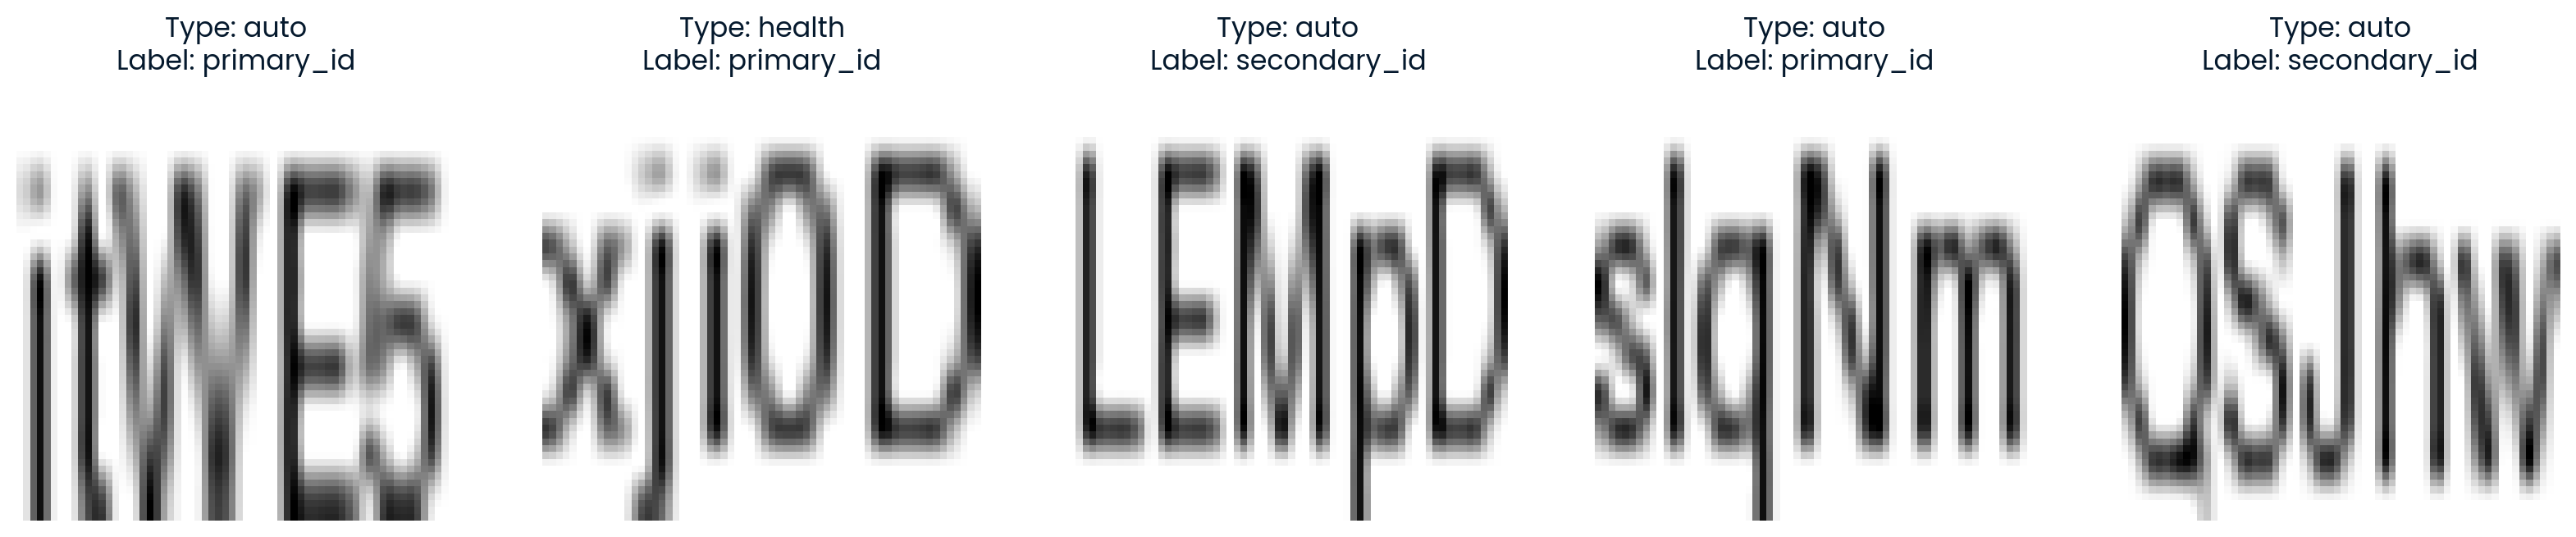

In [70]:
# Import the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from project_utils import ProjectDataset
import pickle 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Load the data
dataset = pickle.load(open('ocr_insurance_dataset.pkl', 'rb'))

# Define a function to visualize codes with their corresponding types and labels 
def show_dataset_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, min(num_images, len(dataset)), figsize=(20, 4))
    for ax, idx in zip(axes, np.random.choice(len(dataset), min(num_images, len(dataset)), False)):
        img, lbl = dataset[idx]
        ax.imshow((img[0].numpy() * 255).astype(np.uint8).reshape(64,64), cmap='gray'), ax.axis('off')
        ax.set_title(f"Type: {list(dataset.type_mapping.keys())[img[1].tolist().index(1)]}\nLabel: {list(dataset.label_mapping.keys())[list(dataset.label_mapping.values()).index(lbl)]}")
    plt.show()

# Inspect 5 codes images from the dataset
show_dataset_images(dataset)

In [71]:
print(next(iter(dataset)))
print('Total numbers of data : ', len(dataset))
print('original image size : {a}\noriginal text length : {b}'.format( a = (dataset)[2][0][0].shape, b = (dataset)[0][0][1].shape ))

((tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.8824, 0.7804, 0.7373],
         [1.0000, 1.0000, 1.0000,  ..., 0.9176, 0.7961, 0.7451],
         [1.0000, 1.0000, 1.0000,  ..., 0.9373, 0.8039, 0.7451]]]), tensor([1., 0., 0., 0., 0.])), 0)
Total numbers of data :  100
original image size : torch.Size([1, 64, 64])
original text length : torch.Size([5])


In [72]:
# Start coding here 

class OCRModel(nn.Module):
    def __init__(self ,num_img_inputs = 1 ,num_text_inputs = 5 , num_img_classes = 128, num_text_classes = 10):
        super().__init__() ### Ensures Model() behave like nn.Module
        self.image_layer = nn.Sequential(
            nn.Conv2d(num_img_inputs, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(16 * int(64/2) * int(64/2), num_img_classes),
        )
        self.text_layer = nn.Sequential(
            nn.Linear(num_text_inputs, 16),
            nn.ReLU(),
            nn.Linear(16, num_text_classes),
        )
        self.classifier = nn.Sequential(
            nn.Linear(num_img_classes + num_text_classes, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x_img, x_typ):
        x_image = self.image_layer(x_img)
        x_type = self.text_layer(x_typ)
        x = torch.cat((x_image, x_type), dim=1)
        return self.classifier(x)

In [73]:
model = OCRModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [74]:
# Load the data in batches
train_dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

for epoch in range(10):
    for (img, txt), label in train_dataloader:
        optimizer.zero_grad()
        outputs = model(img, txt)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 1.3443663120269775
Epoch 2, Loss: 0.6320036053657532
Epoch 3, Loss: 0.5946382284164429
Epoch 4, Loss: 0.7287589907646179
Epoch 5, Loss: 0.6945330500602722
Epoch 6, Loss: 0.7056877017021179
Epoch 7, Loss: 0.693108081817627
Epoch 8, Loss: 0.705356240272522
Epoch 9, Loss: 0.7315276265144348
Epoch 10, Loss: 0.6013385057449341
